<a href="https://colab.research.google.com/github/anu-006/Retail-Store-Product-Clustering/blob/main/Product_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Knowing the data

In [96]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [97]:
data=pd.read_csv('Demand_Forecasting.csv')
data

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52
...,...,...,...,...,...,...,...,...,...
150145,212638,09/07/13,9984,223245,235.8375,235.8375,0,0,38
150146,212639,09/07/13,9984,223153,235.8375,235.8375,0,0,30
150147,212642,09/07/13,9984,245338,357.6750,483.7875,1,1,31
150148,212643,09/07/13,9984,547934,141.7875,191.6625,0,1,12


In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [99]:
data['store_id'].nunique()

76

In [100]:
data['sku_id'].nunique()

28

# Changing type of column

In [101]:
data['week']=pd.to_datetime(data['week'])
data['month']=data['week'].dt.month
data['week_of_year']=data['week'].dt.isocalendar().week


/tmp/ipykernel_2725/943053334.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['week']=pd.to_datetime(data['week'])


In [102]:
data.drop(columns=['week','record_ID'],inplace=True)

# Dealing with null values

In [103]:
data.dropna(inplace=True)

In [104]:
data.isnull().sum()

,0
store_id,0
sku_id,0
total_price,0
base_price,0
is_featured_sku,0
is_display_sku,0
units_sold,0
month,0
week_of_year,0


# Demand Volatality

In [105]:
store_demand_volatilty=data.groupby('store_id')['units_sold'].apply(lambda x: np.std(x)/np.mean(x)).reset_index(name='Store_Demand_Volatility')
product_demand_volatility=data.groupby('sku_id')['units_sold'].apply(lambda x: np.std(x) / np.mean(x) ).reset_index( name= 'Product_Demand_Volatility')


# Product Responsiveness

In [106]:
promo_sales=data[data['is_featured_sku']==1].groupby('sku_id')['units_sold'].mean()
promo_sales

,units_sold
sku_id,
216233,56.225131
216418,115.572271
216419,103.750760
216425,38.600000
217217,39.966805
217390,98.190751
217777,42.131868
219009,319.866591
219029,174.518182


In [107]:
non_promo_sales=data[data['is_featured_sku']==0].groupby('sku_id')['units_sold'].mean()
non_promo_sales

,units_sold
sku_id,
216233,46.432345
216418,87.861193
216419,70.943444
216425,33.836000
217217,20.901242
217390,60.142757
217777,23.595120
219009,77.050716
219029,36.259633


In [108]:
product_responsiveness = (promo_sales - non_promo_sales).reset_index(name='Product_Responsiveness')
product_responsiveness = product_responsiveness.fillna(0).astype('int32')

In [109]:
data['discount']=data['base_price']-data['total_price']

# Product Diversity Index

In [110]:
product_diversity_index=data.groupby('store_id')['sku_id'].nunique().reset_index(name='Product_Diversity_Index')
product_diversity_index

,store_id,Product_Diversity_Index
0,8023,21
1,8058,15
2,8063,19
3,8091,9
4,8094,24
...,...,...
71,9890,13
72,9909,14
73,9954,17
74,9961,17


In [111]:
data.describe()

,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,month,week_of_year,discount
count,150149.000000,150149.000000,150149.000000,150149.000000,150149.000000,150149.000000,150149.000000,150149.000000,150149.0,150149.000000
mean,9199.420935,254761.195226,206.626751,219.424262,0.095612,0.133201,51.674543,6.130783,24.992361,12.797511
std,615.593192,85547.587866,103.308516,110.960204,0.294059,0.339793,60.207962,3.438239,14.867962,31.641315
min,8023.000000,216233.000000,41.325000,61.275000,0.000000,0.000000,1.000000,1.000000,1.0,-106.875000
25%,8562.000000,217217.000000,130.387500,133.237500,0.000000,0.000000,20.000000,3.000000,12.0,0.000000
50%,9371.000000,222087.000000,198.075000,205.912500,0.000000,0.000000,35.000000,6.000000,24.0,0.000000
75%,9731.000000,245338.000000,233.700000,234.412500,0.000000,0.000000,62.000000,9.000000,38.0,0.000000
max,9984.000000,679023.000000,562.162500,562.162500,1.000000,1.000000,2876.000000,12.000000,52.0,250.800000


In [112]:
data

,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,month,week_of_year,discount
0,8091,216418,99.0375,111.8625,0,0,20,1,3,12.8250
1,8091,216419,99.0375,99.0375,0,0,28,1,3,0.0000
2,8091,216425,133.9500,133.9500,0,0,19,1,3,0.0000
3,8091,216233,133.9500,133.9500,0,0,44,1,3,0.0000
4,8091,217390,141.0750,141.0750,0,0,52,1,3,0.0000
...,...,...,...,...,...,...,...,...,...,...
150145,9984,223245,235.8375,235.8375,0,0,38,9,36,0.0000
150146,9984,223153,235.8375,235.8375,0,0,30,9,36,0.0000
150147,9984,245338,357.6750,483.7875,1,1,31,9,36,126.1125
150148,9984,547934,141.7875,191.6625,0,1,12,9,36,49.8750


In [113]:
data.columns

Index(['store_id', 'sku_id', 'total_price', 'base_price', 'is_featured_sku',
       'is_display_sku', 'units_sold', 'month', 'week_of_year', 'discount'],
      dtype='object')

In [114]:
store_grp=data.groupby('store_id').agg({
    'sku_id' : 'nunique',
    'total_price' : ['mean','std'],
    'base_price' : ['mean', 'std'],
    'is_featured_sku': 'mean',
    'is_display_sku' : 'mean',
    'units_sold' : ['mean','std'],
    'month' : 'nunique',
    'week_of_year' : 'nunique',
    'discount' : ['mean','std'],

})

In [115]:
# Flatten the MultiIndex columns of store_grp
store_grp.columns = ['_'.join(col).strip() for col in store_grp.columns.values]

# Now perform the join
store_grp = store_grp.join(store_demand_volatilty.set_index('store_id'))

In [116]:
store_grp

,sku_id_nunique,total_price_mean,total_price_std,base_price_mean,base_price_std,is_featured_sku_mean,is_display_sku_mean,units_sold_mean,units_sold_std,month_nunique,week_of_year_nunique,discount_mean,discount_std,Store_Demand_Volatility
store_id,,,,,,,,,,,,,,
8023,21,231.463063,123.882801,247.386525,131.902317,0.095604,0.180952,108.600000,101.251594,12,51,15.923462,38.468086,0.932164
8058,15,220.944058,109.635499,237.061904,117.869920,0.094359,0.154872,52.747692,48.506107,12,51,16.117846,37.078197,0.919351
8063,19,209.705769,91.405879,220.264038,98.786073,0.101215,0.100810,34.714980,35.161718,12,51,10.558269,26.981982,1.012664
8091,9,172.272756,69.639930,181.312372,70.188617,0.068376,0.069231,32.805983,33.272252,12,51,9.039615,21.458839,1.013779
8094,24,208.766611,101.771141,221.591154,108.393014,0.097436,0.120192,41.821795,43.558398,12,51,12.824543,30.344567,1.041357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9890,13,188.861405,97.656155,200.994564,103.996326,0.072781,0.166864,59.554438,51.456417,12,51,12.133158,29.969249,0.863768
9909,14,211.796106,114.938777,225.278798,123.594919,0.098901,0.153846,66.397802,69.780753,12,51,13.482692,34.142213,1.050661
9954,17,224.677042,106.577893,238.132653,116.490896,0.115837,0.090498,34.275566,33.165519,12,51,13.455611,32.533481,0.967395


In [117]:
sku_grp=data.groupby('sku_id').agg({
    'store_id' : 'nunique',
    'total_price' : ['mean','std'],
    'base_price' : ['mean', 'std'],
    'is_featured_sku': 'mean',
    'is_display_sku' : 'mean',
    'units_sold' : ['mean','std'],
    'month' : 'nunique',
    'week_of_year' : 'nunique',
    'discount' : ['mean','std'],

})

In [118]:
# Flatten the MultiIndex columns of sku_grp
sku_grp.columns = ['_'.join(col).strip() for col in sku_grp.columns.values]



In [119]:
sku_grp


,store_id_nunique,total_price_mean,total_price_std,base_price_mean,base_price_std,is_featured_sku_mean,is_display_sku_mean,units_sold_mean,units_sold_std,month_nunique,week_of_year_nunique,discount_mean,discount_std
sku_id,,,,,,,,,,,,,
216233,74,124.942208,8.312769,128.101871,7.411920,0.039709,0.019127,46.821206,27.104248,12,51,3.159663,6.448091
216418,68,91.982702,14.211997,94.688268,12.710890,0.038348,0.298416,88.923869,71.905857,12,51,2.705566,7.084997
216419,67,92.349162,14.164846,94.908763,12.745741,0.037773,0.302296,72.182664,52.488434,12,51,2.559601,7.053775
216425,66,125.156355,8.547538,128.285210,7.489449,0.038462,0.024126,34.019231,25.305237,12,51,3.128855,6.668508
217217,26,235.160836,25.081843,241.532862,31.841243,0.071302,0.113905,22.260651,16.738058,12,51,6.372027,20.560300
217390,70,150.867334,14.155578,158.990538,12.576327,0.057033,0.036264,62.312747,51.706776,12,51,8.123205,12.680152
217777,20,232.402976,17.062808,237.607788,22.805026,0.070000,0.116923,24.892692,16.068570,12,51,5.204813,17.005451
219009,75,197.891577,26.524297,208.554815,16.499023,0.089949,0.080000,98.891692,116.450121,12,51,10.663238,25.697835
219029,73,301.910425,40.984853,314.075856,17.067311,0.081138,0.077555,47.477661,58.761333,12,51,12.165431,37.354222


# Scaling (product)

In [120]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(sku_grp)

In [121]:
np.isnan(x_scaled).sum()

np.int64(0)

# PCA (product)

In [122]:
pca=PCA(n_components=2)
pca_output=pca.fit_transform(x_scaled)
pca_output

array([[-2.86878638, -0.11632839],
       [-2.86314059,  2.17326962],
       [-2.6335303 ,  1.35321365],
       [-2.69212708, -0.59927682],
       [ 0.0810747 , -1.45760377],
       [-2.23354332,  0.87413036],
       [-0.43420076, -1.53068478],
       [-1.53614272,  3.57662617],
       [ 0.48542737,  1.32394859],
       [ 0.90079793, -1.09228615],
       [-0.1921665 ,  1.79410239],
       [-0.79671688,  0.96130796],
       [-0.29080187,  2.1312692 ],
       [-0.91642815,  2.37337777],
       [ 5.10807895,  1.85522273],
       [ 5.38364545,  1.20219657],
       [-2.38468812, -0.27928795],
       [ 0.54871163, -1.77478068],
       [-1.37387044, -0.95622786],
       [ 0.15554829, -2.00525526],
       [-1.28051606, -1.33216107],
       [ 5.65696929,  0.40448953],
       [ 0.98034786, -1.9530964 ],
       [-0.54486033, -1.623729  ],
       [-1.59012411, -1.46925045],
       [ 4.75271836, -0.41630862],
       [ 0.95782907, -1.70139027],
       [-0.37950527, -1.71548707]])

In [123]:
pca_df = pd.DataFrame(pca_output, columns=['PCA1', 'PCA2'], index=sku_grp.index)
data = data.merge(pca_df, on='sku_id', how='left')

In [124]:
wcss=[]

for i in range(1,11):
  kmeans=KMeans(n_clusters=i)
  kmeans.fit_predict(x_scaled)
  wcss.append(kmeans.inertia_)


In [125]:
wcss

[308.00000000000006,
 177.18401100129893,
 115.94971554334671,
 92.78343700916545,
 95.85722777402367,
 57.90297300120688,
 44.10828329799078,
 37.66201782205886,
 33.68052296820545,
 30.223829823575336]

Text(0.5, 1.0, 'wcss v/s range')

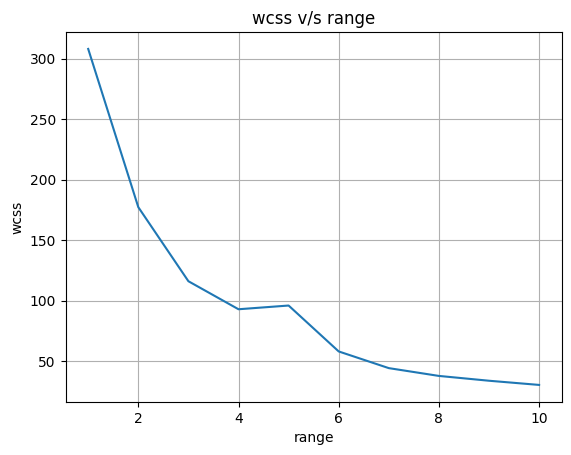

In [126]:
sns.lineplot(x=range(1,11),y=wcss)
plt.grid()
plt.ylabel('wcss')
plt.xlabel('range')
plt.title('wcss v/s range')

In [127]:
kmeans=KMeans(n_clusters=6)
cluster_output=kmeans.fit_predict(x_scaled)



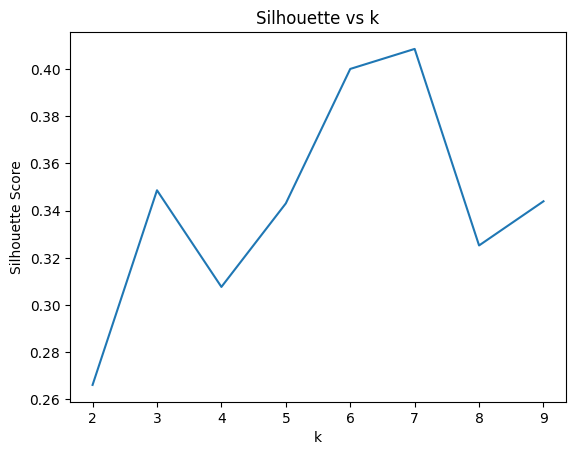

In [128]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    silhouette_scores.append(silhouette_score(x_scaled, labels))
plt.plot(range(2,10), silhouette_scores)
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette vs k')
plt.show()

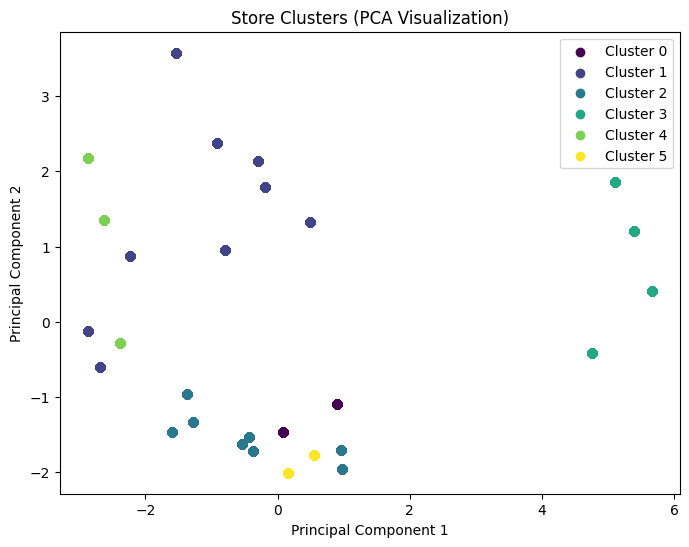

In [129]:
sku_clusters = pd.Series(cluster_output, index=sku_grp.index, name='cluster_output')
data['cluster_output'] = data['sku_id'].map(sku_clusters)

plt.figure(figsize=(8,6))
n_clusters = len(data['cluster_output'].unique())
colors_map = plt.colormaps.get_cmap('viridis')

for cluster_id in sorted(data['cluster_output'].unique()):
    cluster_data = data[data['cluster_output'] == cluster_id]
    # Normalize cluster_id to get a color from the colormap
    color = colors_map(cluster_id / (n_clusters - 1) if n_clusters > 1 else 0.5)
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster_id}', color=color)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Store Clusters (PCA Visualization)')
plt.legend()
plt.show()

In [130]:
sku_grp = sku_grp.join(sku_clusters)
cluster_summary = sku_grp.groupby('cluster_output').mean().round(2)
cluster_summary

,store_id_nunique,total_price_mean,total_price_std,base_price_mean,base_price_std,is_featured_sku_mean,is_display_sku_mean,units_sold_mean,units_sold_std,month_nunique,week_of_year_nunique,discount_mean,discount_std
cluster_output,,,,,,,,,,,,,
0,27.0,240.15,29.31,248.82,36.88,0.07,0.13,24.65,18.57,12.0,51.0,8.67,23.87
1,70.0,191.67,23.08,202.64,12.74,0.09,0.08,59.56,60.83,12.0,51.0,10.96,21.40
2,18.5,233.36,20.42,243.00,10.77,0.05,0.13,21.96,14.82,12.0,51.0,9.64,19.26
3,33.0,436.52,63.41,477.84,24.38,0.25,0.22,25.35,25.63,12.0,51.0,41.32,62.91
4,60.0,93.16,14.00,95.78,12.57,0.04,0.27,68.82,52.54,12.0,51.0,2.62,7.04
5,5.5,106.27,31.15,128.56,32.72,0.07,0.09,18.54,14.55,12.0,51.0,22.29,35.58


<Axes: >

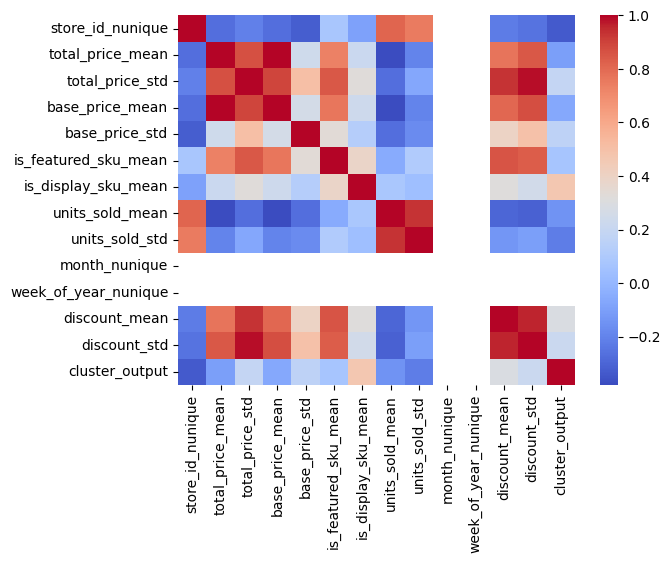

In [143]:
sns.heatmap(sku_grp.corr(), cmap='coolwarm')


In [131]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Silhouette Score:", silhouette_score(x_scaled, cluster_output))
print("Davies–Bouldin Index:", davies_bouldin_score(x_scaled, cluster_output))

Silhouette Score: 0.3696292887170704
Davies–Bouldin Index: 0.8030740013663347


Silhouette > 0.5 → good separation.

Davies–Bouldin < 1.5 → compact clusters.

#**Product Analysis**

# Cluster 0 = Core products
# Cluster 1 = Popular products
# Cluster 2 = Promo‑dependent products
# Cluster 3 = Slow movers products
# Cluster 4 = Premium products
# Cluster 6 = Budget products




---



# Store Clustering


# Scaling (store)

In [132]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(store_grp)
x_scaled

array([[ 1.42621388,  1.63990553,  1.51173649, ...,  1.37247348,
         1.54781307, -0.53127883],
       [-0.04851068,  1.01384156,  0.66949359, ...,  1.45051578,
         1.27884122, -0.60327223],
       [ 0.93463903,  0.34496774, -0.40816781, ..., -0.78156501,
        -0.67498291, -0.07896699],
       ...,
       [ 0.44306418,  1.23601911,  0.48874029, ...,  0.38167109,
         0.39934575, -0.33332333],
       [ 0.44306418,  0.17156706,  0.41326654, ...,  0.50981441,
         0.71787012,  0.00934178],
       [ 0.44306418, -1.03138617, -0.74747941, ..., -0.82520595,
        -0.90098402,  0.5330246 ]])

# PCA (store)

In [133]:
pca=PCA(n_components=2)
pca_output=pca.fit_transform(x_scaled)
pca_output

array([[ 5.17940613e+00, -1.83251903e+00],
       [ 2.32002907e+00,  2.39529664e-01],
       [-7.43632281e-01,  1.32526263e+00],
       [-4.99828998e+00, -1.07610209e+00],
       [ 7.28372655e-01,  7.52640296e-01],
       [ 2.04398131e+00, -1.39135886e+00],
       [ 1.15120083e+00,  2.55734459e+00],
       [-2.32005761e+00,  9.09720171e-01],
       [ 3.20230141e+00, -1.06386738e+00],
       [ 9.36229345e-01,  1.15441715e+00],
       [-8.84310539e-01,  1.70354910e+00],
       [-5.43785405e-01,  1.42742210e+00],
       [ 3.94233605e+00, -1.41088404e-01],
       [ 1.51895267e+00,  3.23573677e-01],
       [ 4.29166482e-01,  1.69630768e+00],
       [ 2.82309620e+00,  1.17370860e+00],
       [-1.25099080e+00,  1.64497766e+00],
       [ 3.25039520e+00, -3.57644161e-01],
       [ 2.88328946e+00, -1.74664371e+00],
       [ 1.17477634e-01,  2.06686762e+00],
       [ 1.79309092e+00,  1.86610653e+00],
       [-8.09287024e+00, -1.03870578e+00],
       [-1.39921470e+00, -3.55389009e-01],
       [ 9.

In [134]:
pca_df=pd.DataFrame(pca_output,columns=['PCA1','PCA2'],index=store_grp.index)
data=data.merge(pca_df,on='store_id',how='left')

In [135]:
wcss=[]

for i in range(1,11):
  kmeans=KMeans(n_clusters=i)
  kmeans.fit_predict(x_scaled)
  wcss.append(kmeans.inertia_)


In [136]:
wcss

[912.0000000000001,
 567.8840140369844,
 430.77484784731456,
 385.65797587762415,
 365.07900740685824,
 294.4860569953217,
 284.91848059190727,
 265.1360865055986,
 247.32048143725518,
 246.77468448766734]

Text(0.5, 1.0, 'wcss v/s range')

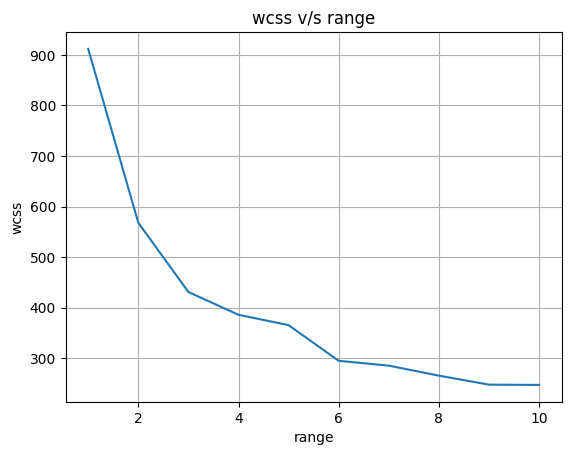

In [137]:
sns.lineplot(x=range(1,11),y=wcss)
plt.grid()
plt.ylabel('wcss')
plt.xlabel('range')
plt.title('wcss v/s range')

In [138]:
kmeans=KMeans(n_clusters=3)
cluster_output=kmeans.fit_predict(x_scaled)

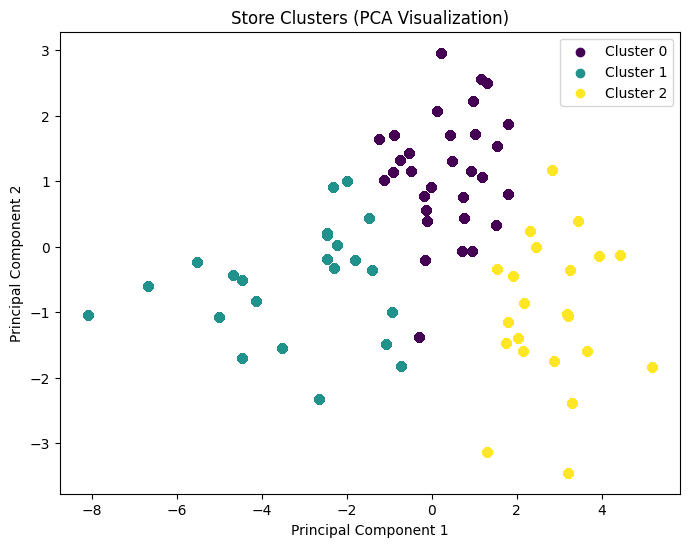

In [139]:
# Remove any existing PCA columns from data to avoid conflicts
pca_cols_to_drop = [col for col in data.columns if col.startswith('PCA')]
if pca_cols_to_drop:
    data = data.drop(columns=pca_cols_to_drop)

# Ensure PCA components from store_grp are correctly merged
pca_df_store = pd.DataFrame(pca_output, columns=['PCA1','PCA2'], index=store_grp.index)
data = data.merge(pca_df_store, on='store_id', how='left')

store_clusters = pd.Series(cluster_output, index=store_grp.index, name='cluster_output')
data['cluster_output'] = data['store_id'].map(store_clusters)

plt.figure(figsize=(8,6))
n_clusters = len(data['cluster_output'].unique())
colors_map = plt.colormaps.get_cmap('viridis')

for cluster_id in sorted(data['cluster_output'].unique()):
    cluster_data = data[data['cluster_output'] == cluster_id]
    # Normalize cluster_id to get a color from the colormap
    color = colors_map(cluster_id / (n_clusters - 1) if n_clusters > 1 else 0.5)
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster_id}', color=color)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Store Clusters (PCA Visualization)')
plt.legend()
plt.show()

In [140]:
store_grp['cluster_output'] = store_clusters
cluster_summary=store_grp.groupby('cluster_output').mean().round(2)
cluster_summary

,sku_id_nunique,total_price_mean,total_price_std,base_price_mean,base_price_std,is_featured_sku_mean,is_display_sku_mean,units_sold_mean,units_sold_std,month_nunique,week_of_year_nunique,discount_mean,discount_std,Store_Demand_Volatility
cluster_output,,,,,,,,,,,,,,
0,15.74,210.63,102.14,223.20,110.13,0.10,0.12,40.37,40.41,12.0,51.0,12.57,30.82,1.01
1,12.39,182.97,78.81,192.89,82.60,0.08,0.10,37.40,40.14,12.0,51.0,9.92,24.66,1.08
2,17.36,216.34,113.29,231.46,121.70,0.09,0.17,74.44,74.62,12.0,51.0,15.11,36.06,1.00


In [141]:

print("Silhouette Score:", silhouette_score(x_scaled, cluster_output))
print("Davies–Bouldin Index:", davies_bouldin_score(x_scaled, cluster_output))

Silhouette Score: 0.26238231944408724
Davies–Bouldin Index: 1.2368660579586912


“Store behaviors overlap due to similar promotion cycles.”

#**Store Analysis**

# Cluster 0 = top‑performing stores
# Cluster 1 = low‑activity stores
# Cluster 2 = balanced stores

<Axes: >

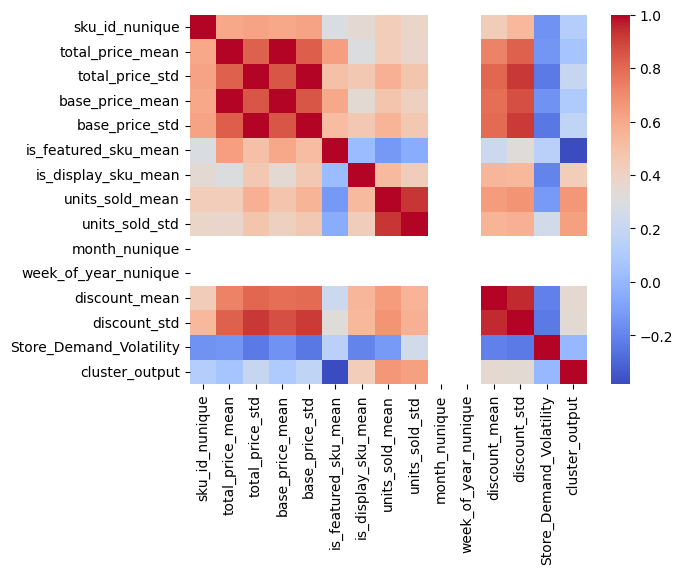

In [142]:
sns.heatmap(store_grp.corr(), cmap='coolwarm')
